<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

In [ ]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

  Cloning https://github.com/dnepple/tprstats-python (to revision colab) to /tmp/pip-req-build-lq41kyjk
  Running command git clone --filter=blob:none --quiet https://github.com/dnepple/tprstats-python /tmp/pip-req-build-lq41kyjk
  Running command git checkout -b colab --track origin/colab
  Switched to a new branch 'colab'
  Branch 'colab' set up to track remote branch 'colab' from 'origin'.
  Resolved https://github.com/dnepple/tprstats-python to commit d5b7ac1c19bfee3ed707aefeeb1cbc04ba8934ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.0 MB/s eta 0:00:00
  Created wheel for tprstats: filename=tprstats-0.1.0-py3-none-any.whl size=11433 sha256=e38399a69178cc4de2bccb588e13689ac49ea560fcd08e774bb7d0755111c884
  Stored in directory: /tmp/pip-ephem-wheel-cache-m2gqamjq/wheels/5d/0e/3a/ef7ae3e58a9bf61b5c91546d764aaf5ac5df485b9ce38295fe
Succ

In [ ]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder
%cd '/content/drive/MyDrive/SDM'

Mounted at /content/drive
/content/drive/MyDrive/SDM


In [ ]:
import pandas
import numpy
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Stat Mini4 Script Slide Set 7
## Choosing Functional Form
Import Dataset Boston_Condos_572.xlsx

In [ ]:
Boston_Condos_572 = pandas.read_excel("data/Boston_Condos_572.xlsx")

In [ ]:
# Boston Condominiums
# CDIST is measured in feet. Let's convert to thousands of feet
Boston_Condos_572["CDIST"] = Boston_Condos_572["CDIST"] / 1000

In [ ]:
Boston_Condos_572.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Observation,572.0,286.500000,165.266452,1.000000,143.750000,286.500000,429.25,572.0
PRICE,572.0,141247.284965,85706.850830,26000.000000,80000.000000,120750.000000,180000.00,595000.0
BECST,572.0,0.473776,0.499749,0.000000,0.000000,0.000000,1.00,1.0
BHILL,572.0,0.017483,0.131175,0.000000,0.000000,0.000000,0.00,1.0
COMAVE,572.0,0.353147,0.478366,0.000000,0.000000,0.000000,1.00,1.0
MARST,572.0,0.155594,0.362788,0.000000,0.000000,0.000000,0.00,1.0
BATH,572.0,1.417832,0.575535,1.000000,1.000000,1.000000,2.00,4.0
BED,572.0,1.431818,0.807518,0.000000,1.000000,1.000000,2.00,4.0
PARK,572.0,0.250000,0.433392,0.000000,0.000000,0.000000,0.25,1.0
SQFT,572.0,920.351399,438.958248,216.000000,588.750000,790.000000,1169.50,2511.0


In [ ]:
# Estimate Linear Regression
Reg_Condos=tprstats.model("cs", "PRICE~BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK+SQFT", Boston_Condos_572)
Reg_Condos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.762
No. Observations:                 572   F-statistic:                     94.25
Covariance Type:                  HC1   Prob (F-statistic):          2.96e-106
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.905e+04   9532.003     -3.048      0.002   -4.78e+04   -1.03e+04
BATH        7694.5909   8170.728      0.942      0.347   -8354.305    2.37e+04
BECST       1.553e+04   4350.641      3.569      0.000    6980.340    2.41e+04
BED         7821.2422   5003.691      1.563      0.119   -2006.978    1.76e+04
BHILL       6.095e+04   1.52e+04      3.999      0.000     3.1e+04    9.09e+04
CDIST        578.4522    739.883      0.782      0.435    -874.822    2031.726
FLOORS      -604.9486    509.313     -1.188      0.235   -1605.339     395.442
MARST       1.074e+04   5828.839      1.843      0.066    -706.985    2.22e+04
PARK        2.168e+04   5676.670      3.819      0.000    1.05e+04    3.28e+04
SQFT         145.9019     13.291     10.977      0.000     119.796     172.008
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 8.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Test functional form. We obtain low p values
Reg_Condos.ramsey_test()

,power,pvalue
0,2,2.398763e-02
1,3,1.594274e-10


In [ ]:
# Let's create variables for log price, log square feet, and log cdist  to make plotting easier
Boston_Condos_572["log_PRICE"] = Boston_Condos_572["PRICE"].map(numpy.log)
Boston_Condos_572["log_SQFT"] = Boston_Condos_572["SQFT"].map(numpy.log)
Boston_Condos_572["log_CDIST"] = Boston_Condos_572["CDIST"].map(numpy.log)

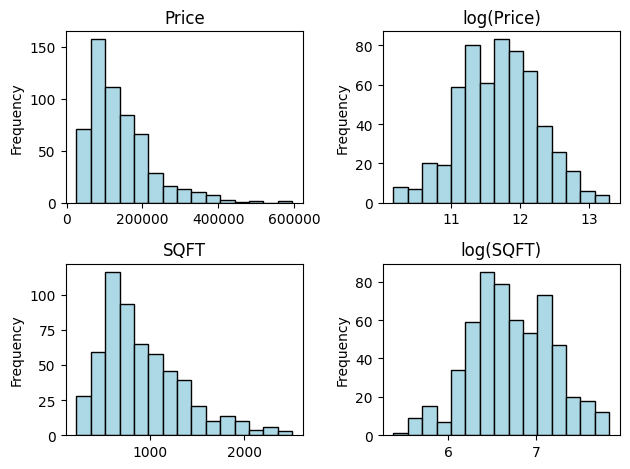

In [ ]:
# Histograms suggest using logarithms of PRICE and SQFT
fig, axes = plt.subplots(nrows=2, ncols=2, tight_layout=True)
Boston_Condos_572["PRICE"].plot.hist(ax=axes[0, 0], title="Price",bins=15,edgecolor="black",
                                     color="lightblue")
Boston_Condos_572["log_PRICE"].plot.hist(ax=axes[0, 1], title="log(Price)",
                                        bins=15,edgecolor="black", color="lightblue")
Boston_Condos_572["SQFT"].plot.hist(ax=axes[1, 0], title="SQFT",bins=15,edgecolor="black",
                                     color="lightblue")
Boston_Condos_572["log_SQFT"].plot.hist(ax=axes[1, 1], title="log(SQFT)",
                                       bins=15,edgecolor="black", color="lightblue")
plt.show()

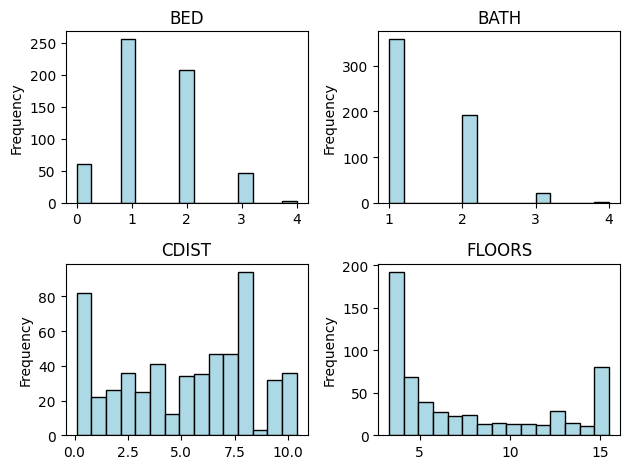

In [ ]:
# Let's view histograms of some additional variables.
fig, axes = plt.subplots(ncols=2,nrows=2,  tight_layout=True)
Boston_Condos_572["BED"].plot.hist(ax=axes[0, 0], title="BED",bins=15,edgecolor="black",
                                     color="lightblue")
Boston_Condos_572["BATH"].plot.hist(ax=axes[0, 1], title="BATH",
                                        bins=15,edgecolor="black", color="lightblue")
Boston_Condos_572["CDIST"].plot.hist(ax=axes[1, 0], title="CDIST",
                                       bins=15,edgecolor="black", color="lightblue")
Boston_Condos_572["FLOORS"].plot.hist(ax=axes[1, 1], title="FLOORS",
                                       bins=15,edgecolor="black", color="lightblue")
plt.show()

From the above plot, we see that there are more one-bedroom units than either units with no bedroom or units with two or three or four bedrooms. Likewise, we see that there are more one-bathroom units than units with two, three, or four bathrooms. We see that distance from the Boston common, CDIST, varies a good deal across the units. The number of floors in buildings occupied by these condominiums also varies substantially across units.

In [ ]:
# Investigate functional form
Log_Reg_Condos1=tprstats.model("cs", "log(PRICE)~log(SQFT)+BATH+BED+CDIST+FLOORS+PARK+BECST+BHILL+MARST", Boston_Condos_572)
Log_Reg_Condos1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(PRICE)   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.828
No. Observations:                 572   F-statistic:                     305.7
Covariance Type:                  HC1   Prob (F-statistic):          5.07e-210
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8367      0.290     16.676      0.000       4.267       5.406
log(SQFT)      1.0045      0.048     20.864      0.000       0.910       1.099
BATH           0.0335      0.031      1.094      0.274      -0.027       0.094
BED            0.0281      0.029      0.970      0.332      -0.029       0.085
CDIST          0.0046      0.004      1.212      0.226      -0.003       0.012
FLOORS        -0.0102      0.003     -4.019      0.000      -0.015      -0.005
PARK           0.1406      0.028      5.041      0.000       0.086       0.195
BECST          0.0597      0.024      2.477      0.014       0.012       0.107
BHILL          0.3012      0.060      5.013      0.000       0.183       0.419
MARST          0.0552      0.034      1.603      0.109      -0.012       0.123
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [ ]:
# Ramsey test
Log_Reg_Condos1.ramsey_test()

,power,pvalue
0,2,0.166757
1,3,0.374514


In above regression, CDIST is not significant. I found this surprising Let's investigate using the logarithm of CDIST instead of CDIST. Note that this is a case in which CDIST is not skewed. However, it is intuitive that the benefit of being close to the Boston common increases at a decreasing rate with distance from the Boston Common. We see from the following regression that the logarithm of CDIST is statistically significant.

In [ ]:
# Investigate functional form
Log_Reg_Condos2= tprstats.model("cs", "log(PRICE) ~ log(SQFT) + BATH + BED + log(CDIST) + FLOORS + PARK + BECST + BHILL + MARST", Boston_Condos_572)
Log_Reg_Condos2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(PRICE)   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.830
No. Observations:                 572   F-statistic:                     321.7
Covariance Type:                  HC1   Prob (F-statistic):          3.51e-215
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8847      0.286     17.055      0.000       4.322       5.447
log(SQFT)      0.9914      0.048     20.677      0.000       0.897       1.086
BATH           0.0370      0.030      1.217      0.224      -0.023       0.097
BED            0.0306      0.029      1.056      0.291      -0.026       0.088
log(CDIST)     0.0283      0.011      2.483      0.013       0.006       0.051
FLOORS        -0.0084      0.003     -3.021      0.003      -0.014      -0.003
PARK           0.1324      0.028      4.776      0.000       0.078       0.187
BECST          0.0699      0.025      2.789      0.005       0.021       0.119
BHILL          0.3442      0.058      5.954      0.000       0.231       0.458
MARST          0.0637      0.035      1.821      0.069      -0.005       0.132
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

From the above plot, we see that there are more one-bedroom units than either units with no bedroom or units with two or three or four bedrooms. Likewise, we see that there are more one-bathroom units than units with two, three, or four bathrooms. We see that distance from the Boston common, CDIST, varies a good deal across the units.

In [ ]:
# Ramsey test
Log_Reg_Condos2.ramsey_test()

,power,pvalue
0,2,0.241611
1,3,0.499855


In [ ]:
# Let's test the null hypothesis that the coefficient of log(SQFT) equals 1
Log_Reg_Condos2.wald_test("log(SQFT)=1")

p-value:  0.858


In [ ]:
# Test the hypothesis that coefficint of BED equals coefficient of BATH
Log_Reg_Condos2.wald_test("BED=BATH")

p-value:  0.893


In [ ]:
# Calculate correlations
Boston_Condos_572["BED"].corr(Boston_Condos_572["BATH"])

np.float64(0.6360640430061608)

In [ ]:
Boston_Condos_572['BED'].corr(Boston_Condos_572['log_SQFT'])

np.float64(0.8066321703182967)

In [ ]:
Boston_Condos_572['BATH'].corr(Boston_Condos_572['log_SQFT'])

np.float64(0.7232950476624733)

As an illustration, suppose we leave out the square foot variable. Note the change in the coefficients and significance levels of the BED and BATH variables.

In [ ]:
Log_Reg_Condos3=tprstats.model("cs", "log(PRICE) ~ BATH + BED + log(CDIST) + FLOORS + PARK + BECST + BHILL + MARST", Boston_Condos_572)
Log_Reg_Condos3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log(PRICE)   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.662
No. Observations:                 572   F-statistic:                     126.5
Covariance Type:                  HC1   Prob (F-statistic):          1.63e-120
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6754      0.069    154.852      0.000      10.540      10.811
BATH           0.3114      0.040      7.853      0.000       0.234       0.389
BED            0.3575      0.029     12.261      0.000       0.300       0.415
log(CDIST)     0.0732      0.017      4.253      0.000       0.039       0.107
FLOORS        -0.0123      0.004     -3.029      0.003      -0.020      -0.004
PARK           0.1780      0.038      4.680      0.000       0.103       0.253
BECST          0.0343      0.034      1.001      0.317      -0.033       0.102
BHILL          0.4565      0.093      4.934      0.000       0.275       0.638
MARST         -0.0184      0.048     -0.382      0.703      -0.113       0.076
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

We now do prediction. We use Log_Reg_Condos2 for our prediction

In [ ]:
Xnew = pandas.DataFrame({
    "SQFT": [1000], "BATH": [2], "BED": [2], "CDIST": [6.3], "FLOORS": [4],  "PARK": [1], "BECST": [1],  "BHILL": [0],"MARST": [0]
    })
Log_Reg_Condos2.prediction_intervals(Xnew, alpha=0.25).map(numpy.exp)

,Predicted,Lower,Upper
0,177929.831399,135174.303659,234208.899507


In [ ]:
yhat=Log_Reg_Condos2.predict()
resid=Log_Reg_Condos2.resid

In [ ]:
hist(yhat)

plt.figure(figsize=(10, 4))
plt.scatter(yhat, resid,color='b')
plt.axhline(y=0, color='r', linestyle='--')
plt.scatter(yhat, resid)
ax.set_title('Histogram of Predicted Values')
ax.set_xlabel('Values')
ax.set_ylabel('Frequency')
plt.show()

High p-values for the Ramsey test suggest that this is a good functional form.

In [ ]:
Log_Reg_Condos2.ramsey_test()

,power,pvalue
0,2,0.241611
1,3,0.499855


There are two prominent outliers in the above plot. One is positive and one is negative. Let's find them and view the data.

In [ ]:
# Find and view the indices of the largest positive and negative residuals
index1=resid.argmax()
index2= resid.argmin()
index1,index2

(np.int64(5), np.int64(368))

Recall the Python convention of numbers beginning with 0. I'll instead use observation numbers. We see from the results above that the outliers are condominiums in rows 6 and 369 of the data, i.e. Observations 6 and 369.  Let's view the information for those two condos. For convenience, I'll refer to these as units 6 and 369. We use the command below to view the information for the two units. The data for Unit 6 show no bedrooms. This may partially account for the under-prediction of price for that unit. If you look at the data file, there are 61 units with no bedrooms. These are likely units with a Murphy bed that can be folded up and stored vertically against a wall when not in use. There must have been some special features of this unit not recorded in the data that resulted in such a high price. On the opposite side, unit 369 has a relatively low price despite having two bedrooms and more square feet of space than Unit 6. Perhaps this unit was not well maintained. If it were feasible to do so, we would check the coding of the data for these two units to make sure there are no coding errors. However, we do not have access to data to check the coding.

It is possible to use AI to help in choosing functional form. In many applications, the data you are using is confidential. Hence, if you use Copilot or ChatGPT, you risk having your data become public. For that reason,it is important that you be able to choose functional form using the approach we studied with the Boston Condos data. As I have emphasized from the outset of our course, the data sets I provided should not be posted on the web and should not be used with Copilot or ChatGPT.

There may be instances in which you are not concerned about confidentiality are you wish to use AI in helping you choose functional form. Hence, I created a data set named Functional_Form_Data_AI.xlsx. The data are not confidential. Let's use CoPilot to choose functional form for the variables in the data.  

This applicatioo illustrates that, in its present form, AI is not very helpful in choosing functional form.

In [ ]:
FuncFormDat = pandas.read_excel("data/Functional_Form_Data_AI.xlsx")

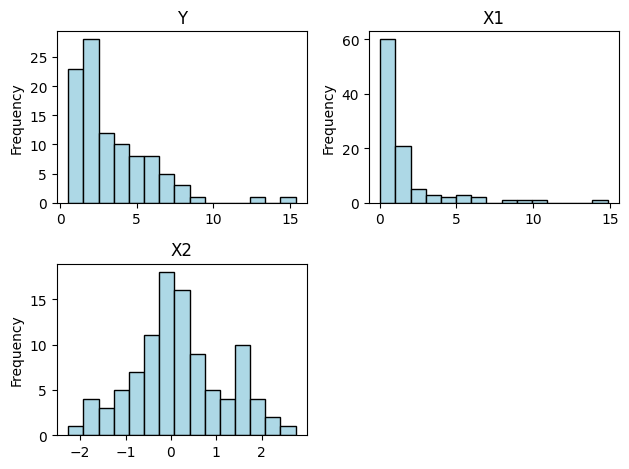

In [ ]:
# Histograms suggest using logarithms of Y and X1 and not taking the log of X2
fig, axes = plt.subplots(nrows=2, ncols=2, tight_layout=True)
FuncFormDat["Y"].plot.hist(ax=axes[0, 0], title="Y",bins=15,edgecolor="black",
                                     color="lightblue")
FuncFormDat["X1"].plot.hist(ax=axes[0, 1], title="X1",
                                        bins=15,edgecolor="black", color="lightblue")
FuncFormDat["X2"].plot.hist(ax=axes[1, 0], title="X2",bins=15,edgecolor="black",
                                     color="lightblue")
axes[1, 1].remove()
plt.show()

In [ ]:
# Let's create variables for log Y and log X1
FuncFormDat["log_Y"] = FuncFormDat["Y"].map(numpy.log)
FuncFormDat["log_X1"] = FuncFormDat["X1"].map(numpy.log)


In [ ]:
FuncFormDat.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Y,100.0,3.356310,2.540651,0.525000,1.592000,2.464000,4.545250,15.378000
X1,100.0,1.615720,2.345604,0.049000,0.482500,0.795000,1.498000,14.823000
X2,100.0,0.182110,1.013993,-2.262000,-0.497000,0.080000,0.833000,2.747000
log_Y,100.0,0.969424,0.698940,-0.644357,0.464970,0.901781,1.514064,2.732938
log_X1,100.0,-0.157566,1.114811,-3.015935,-0.728972,-0.229464,0.404065,2.696180


The above histograms suggest taking logarithms of Y and X1 but not X2. This is done in the following regression.

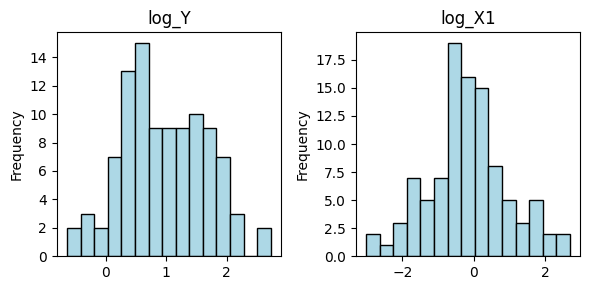

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(6, 3), tight_layout=True)
FuncFormDat["log_Y"].plot.hist(ax=axes[0], title="log_Y",bins=15,edgecolor="black",
                                     color="lightblue")
FuncFormDat["log_X1"].plot.hist(ax=axes[1], title="log_X1",
                                        bins=15,edgecolor="black", color="lightblue")
plt.show()

In [ ]:
OurReg=tprstats.model("cs", "log(Y) ~ log(X1) + X2", FuncFormDat)
OurReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 log(Y)   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
No. Observations:                 100   F-statistic:                     364.6
Covariance Type:                  HC1   Prob (F-statistic):           7.58e-46
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9986      0.027     37.348      0.000       0.946       1.052
log(X1)        0.5164      0.023     22.526      0.000       0.471       0.562
X2             0.2866      0.024     12.057      0.000       0.239       0.334
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

High p-values for the Ramsey test are favorable to this functional form.

In [ ]:
OurReg.ramsey_test()

,power,pvalue
0,2,0.915791
1,3,0.696789


I then investigated whether AI would choose an appropriate functional form. I entered the following into Copilot:  
To estimate a regression, I have data for three variables, Y, X1, and X2. The data are below. Find the appropriate functional form for the variables with Y as dependent variable and X1 and X2 as the dependent variables.  
I then copied the data from Excel and pasted the data into the same window as the above request.  
Copilot then choose the regression shown below along with the statement: Preferred functional form (econometrically sound)

In [ ]:
AIReg=tprstats.model("cs", "log(Y) ~ X1 + X2", FuncFormDat)
AIReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 log(Y)   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.580
No. Observations:                 100   F-statistic:                     64.91
Covariance Type:                  HC1   Prob (F-statistic):           1.28e-18
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6079      0.063      9.664      0.000       0.483       0.733
X1             0.1893      0.033      5.712      0.000       0.124       0.255
X2             0.3056      0.042      7.210      0.000       0.221       0.390
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

Lets do the Ramsey test for the model chosen by AI. We see that the Ramsey test very strongly rejects the functional form chosen by AI. I found it surprising that AI failed in this relatively simple modeling task. This also emphasizes the importance to you of being able to choose an appropriate functional form when you are developing a regression model.

In [ ]:
AIReg.ramsey_test()

,power,pvalue
0,2,0.000005
1,3,0.000004


We now return to the data set for Boston Condominiums and study leverate plots.

In [ ]:
import pandas
import statsmodels.api as sm

In [ ]:
y = Boston_Condos_572.PRICE
X = Boston_Condos_572[
    ["BECST", "BHILL", "COMAVE", "MARST", "BATH", "BED", "PARK", "SQFT", "FLOORS", "CDIST",
    ]
]
#stepwise_regression(y, X, 0.18, features=["BED", "BATH"], verbose=True)

The following commands create a leverage plot of PRICE vs SQFT for the Boston Condominimum Data. The first regression has PRICE as the dependent variable and all explanatory variables except SQFT. The second regression has SQFT as the dependent variable and all explanatory variables except SQFT. The residuals from the first regression are plotted against the residuals from the second regression to create the leverage plot.

In [ ]:
Reg_CondosA=tprstats.model("cs", "PRICE~BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK", Boston_Condos_572)
residP=Reg_CondosA.resid
Reg_CondosB=tprstats.model("cs", "SQFT~BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK", Boston_Condos_572)
residS=Reg_CondosB.resid

In [ ]:
plt.scatter(residP,residS)

The following commands use Python partregress command to create the same leverage plot.

In [ ]:
myreg=tprstats.model("cs", "PRICE~SQFT+BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK",
                          Boston_Condos_572)
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.plot_partregress('PRICE', 'SQFT', ['BATH', 'BECST', 'BED', 'BHILL', 'CDIST', 'FLOORS', 'MARST', 'PARK'], data=Boston_Condos_572, ax=ax
                            ,obs_labels=False)
plt.title('Partial Regression Plot for PRICE vs SQFT')
plt.show()


In [ ]:
myreg=tprstats.model("cs", "PRICE~SQFT+BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK",
                          Boston_Condos_572)
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.plot_partregress('PRICE', 'CDIST', ['SQFT','BATH', 'BECST', 'BED', 'BHILL',  'FLOORS', 'MARST', 'PARK'], data=Boston_Condos_572, ax=ax
                            ,obs_labels=False)
plt.title('Partial Regression Plot for PRICE vs CDIST')
plt.show()


The above commands createe a leverage plot of PRICE vs CDIST for the Boston Condominimum Data. The first regression has PRICE as the dependent variable and all explanatory variables except CDIST. The second regression has CDIST as the dependent variable and all explanatory variables except CDIST. The residuals from the first regression are plotted against the residuals from the second regression to create the leverage plot. This plot is not very informative about the functional form for CDIST

In [ ]:
Boston_Condos_572["log_price"]=log_price=numpy.log(Boston_Condos_572["PRICE"])
Boston_Condos_572["log_sqft"]=log_sqft=numpy.log(Boston_Condos_572["SQFT"])
myreg=tprstats.model("cs", "log_price~log_sqft+BATH+BECST+BED+BHILL+CDIST+FLOORS+MARST+PARK",
                          Boston_Condos_572)
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.plot_partregress('log_price','CDIST', ['log_sqft','CDIST','BATH', 'BECST', 'BED', 'BHILL',  'FLOORS', 'MARST', 'PARK'], data=Boston_Condos_572, ax=ax
                            ,obs_labels=False)
plt.title('Partial Regression Plot for PRICE vs CDIST')
plt.show()
